---
# Tutoriumsblatt 2: Visualisierung passender Aufgaben
SS 2025 – Tutorium: Markovsche Ketten <br>
[Ilias Seite zum Kurs](https://ilias.studium.kit.edu/goto.php?target=crs_2640974&client_id=produktiv) <br>
Dominik Ebert

---

---
## T9 (Karriereleiter)
---

## 1. Übgergangswahrscheinlichkeit

In [40]:
import numpy as np

In [41]:
# Implementierung der Übergangsmatrix P
states = np.array([0, 1, 2, 3, 4, 5, 6])

states_absorptions = np.array([5, 6])
N = len(states)

# P ist eine Numpy-Matrix mit N Zeilen und N Spalten
P = np.zeros((N, N))

# Die Übergangswahrscheinlichkeiten werden in die Matrix P eingetragen
P[0, 1] = 3/5; P[0, 6] = 2/5
P[1, 2] = 0.5; P[1, 6] = 0.5
P[2, 3] = 0.5; P[2, 6] = 0.5
P[3, 4] = 1/3; P[3, 6] = 2/3
P[4, 5] = 1/10; P[4, 6] = 9/10
P[5, 5] = 1
P[6, 6] = 1
# Die Matrix P ist jetzt vollständig definiert
print(P)

[[0.         0.6        0.         0.         0.         0.
  0.4       ]
 [0.         0.         0.5        0.         0.         0.
  0.5       ]
 [0.         0.         0.         0.5        0.         0.
  0.5       ]
 [0.         0.         0.         0.         0.33333333 0.
  0.66666667]
 [0.         0.         0.         0.         0.         0.1
  0.9       ]
 [0.         0.         0.         0.         0.         1.
  0.        ]
 [0.         0.         0.         0.         0.         0.
  1.        ]]


#### (c) Nach wievielen Schritten wird im Durchschnitt ein absorbierender Zustand erreicht, falls die Kette im Zustand 1 startet ?

Im Folgenden visualisieren wir uns die Mittlere Absorptionszeit von zufällig generierten Pfade beginnend in Zustand 1 (hier mit Index 0).

In [42]:
def create_random_walk():
    
    # Positionen der Zustände
    state_positions = np.array([(i, 0) for i in range(N)])
    
    # Startposition (Zustand 1)
    current_state = 0
    path = [current_state]
    
    # Zufällige Schritte generieren
    i = 1
    next_state = np.random.choice(states, p=P[current_state])
    # i zählt die Schritte bis zur Absorption
    while next_state < 5:
        path.append(next_state)
        current_state = next_state
        i += 1
        next_state = np.random.choice(states, p=P[current_state])
    path.append(next_state)
    return path, i

In [43]:
create_random_walk()

([0, 6], 1)

In [44]:
# Statische Visualisierung erstellen
path_num = 10000
steps = []
paths = []
for i in range(path_num):
    (path, i) = create_random_walk()
    steps.append(i)
    paths.append(path)


steps = np.array(steps)



In [45]:
steps

array([1, 2, 1, ..., 2, 2, 1])

In [46]:
paths

[[0, 6],
 [0, 1, 6],
 [0, 6],
 [0, 6],
 [0, 1, 2, 3, 4, 6],
 [0, 1, 2, 3, 6],
 [0, 6],
 [0, 6],
 [0, 6],
 [0, 1, 6],
 [0, 6],
 [0, 1, 2, 3, 6],
 [0, 6],
 [0, 6],
 [0, 1, 2, 6],
 [0, 1, 2, 6],
 [0, 1, 2, 6],
 [0, 1, 6],
 [0, 6],
 [0, 1, 6],
 [0, 6],
 [0, 1, 6],
 [0, 6],
 [0, 6],
 [0, 6],
 [0, 1, 2, 6],
 [0, 1, 2, 6],
 [0, 6],
 [0, 1, 6],
 [0, 1, 2, 6],
 [0, 1, 6],
 [0, 1, 6],
 [0, 1, 6],
 [0, 1, 6],
 [0, 1, 2, 3, 6],
 [0, 6],
 [0, 1, 2, 6],
 [0, 6],
 [0, 6],
 [0, 1, 6],
 [0, 6],
 [0, 1, 2, 6],
 [0, 6],
 [0, 1, 2, 6],
 [0, 6],
 [0, 1, 6],
 [0, 1, 6],
 [0, 6],
 [0, 1, 2, 6],
 [0, 1, 2, 6],
 [0, 1, 6],
 [0, 1, 6],
 [0, 1, 6],
 [0, 1, 2, 6],
 [0, 1, 6],
 [0, 1, 2, 3, 4, 6],
 [0, 6],
 [0, 1, 2, 6],
 [0, 1, 2, 3, 6],
 [0, 1, 6],
 [0, 6],
 [0, 6],
 [0, 6],
 [0, 1, 2, 6],
 [0, 6],
 [0, 1, 6],
 [0, 6],
 [0, 6],
 [0, 1, 6],
 [0, 6],
 [0, 1, 2, 6],
 [0, 1, 6],
 [0, 1, 2, 6],
 [0, 1, 6],
 [0, 6],
 [0, 6],
 [0, 6],
 [0, 1, 6],
 [0, 6],
 [0, 1, 6],
 [0, 1, 2, 3, 6],
 [0, 6],
 [0, 6],
 [0, 1, 2, 3, 6]

In [47]:
steps.mean()

2.0979

In [48]:
import matplotlib.pyplot as plt

[1.         1.5        1.33333333 ... 2.0980196  2.0980098  2.0979    ]


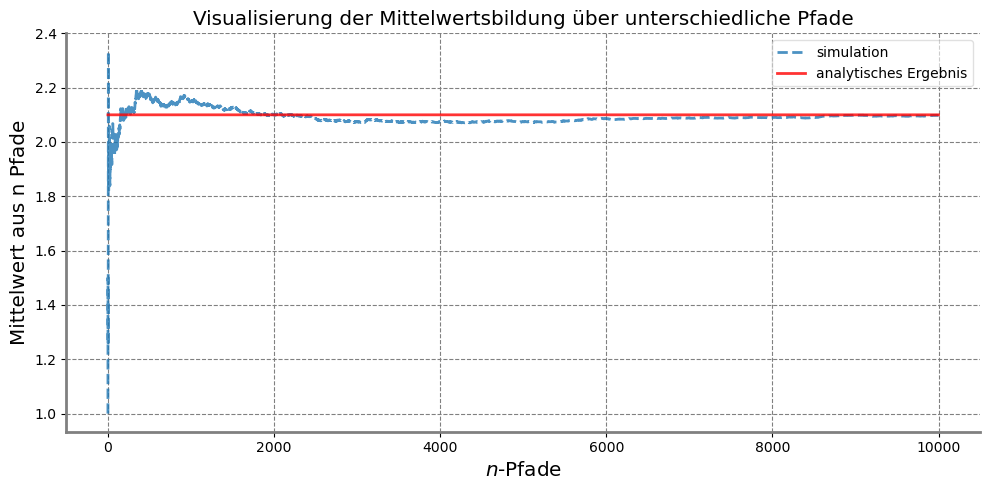

In [50]:
# Bereich für die x-Achse
x_steps = np.linspace(0, path_num, path_num+1)

# Plot erstellen
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot()
ax.grid(True, linestyle='--', color='grey')
ax.set_axisbelow = False
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

steps_mean_iteration = []
for i in range(path_num):
    steps_mean_iteration.append(steps[:i+1].mean())

steps_mean_iteration = np.array(steps_mean_iteration)

print(steps_mean_iteration)
ax.plot(x_steps[:-1], steps_mean_iteration, alpha=0.8, linewidth=2, linestyle='--', label="simulation")
ax.plot(x_steps[:-1], np.ones(x_steps[:-1].shape)*2.1, alpha=0.8, linewidth=2, linestyle='-', color="r", label="analytisches Ergebnis")

# Legende und Achsentitel
legend = ax.legend(fontsize="medium", markerscale=1, framealpha=0.6, loc="upper right")
ax.set_xlabel('$n$-Pfade', fontsize='x-large')
ax.set_ylabel('Mittelwert aus n Pfade', fontsize='x-large')
ax.set_title('Visualisierung der Mittelwertsbildung über unterschiedliche Pfade', fontsize='x-large')
plt.tight_layout()
plt.show()